# Umubyeyi: Complete Machine-Learning and Conversational-System Notebook

This notebook contains the complete reproducible evidence for Umubyeyi. It does not hide training inside project scripts.

**Two separate tasks are implemented:**

1. **Screening-risk classification:** seven classical ML algorithms learn from 800 real participant records. The target is elevated EPDS screening risk, not a medical diagnosis.
2. **Conversational support:** bilingual source-grounded retrieval supplies postpartum wellbeing information. A local pretrained language model may phrase the retrieved evidence, but it was not trained by the tabular dataset.

The structured participant rows must never be treated as question-and-answer conversations.

In [1]:
from pathlib import Path
import json, os, sys, time, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore', category=UserWarning)
SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
DATA = ROOT / 'data' / 'postpartum_depression' / 'PPD_dataset_v3.csv'
DICTIONARY = ROOT / 'data' / 'postpartum_depression' / 'PPD_Data_Dictionary_v3.csv'
KNOWLEDGE = ROOT / 'data' / 'knowledge' / 'postpartum_wellbeing.json'
print('Project root:', ROOT)

Project root: C:\Users\pc\Desktop\UMUBYEYI


## 1. Data provenance and audit

The dataset is *Data for Postpartum Depression Prediction in Bangladesh*, Mendeley Data version 3, DOI `10.17632/4nznnrk8cg.3`, licensed CC BY 4.0. It covers Bangladesh and up to 24 months postpartum; therefore it is not clinical validation for Rwanda or specifically first-time mothers.

In [2]:
df = pd.read_csv(DATA)
dictionary = pd.read_csv(DICTIONARY)
audit = pd.Series({
    'rows': len(df),
    'columns': len(df.columns),
    'duplicate rows': int(df.duplicated().sum()),
    'missing cells': int(df.isna().sum().sum()),
    'EPDS High': int((df['EPDS Result'] == 'High').sum()),
    'EPDS Medium': int((df['EPDS Result'] == 'Medium').sum()),
    'EPDS Low': int((df['EPDS Result'] == 'Low').sum()),
})
display(audit.to_frame('value'))
display(dictionary.head(10))

,value
rows,800
columns,70
duplicate rows,0
missing cells,4312
EPDS High,350
EPDS Medium,190
EPDS Low,260


,Column Name,Short Column Name,Description,Data Type,Units,Example Value,Response Options,Remarks
0,Your age,Age,Age range of the respondent,Integer,Years,25,Range: 18 or up (open-ended integer),Respondent's age in years
1,Current residence,Residence,Current place of residence,String,Category,City,City | Village,Respondent's place of residence
2,Level of education,Education Level,Highest level of education attained,String,Category,University,University | College | High School | Primary |...,Highest level of education attained
3,Marital status,Marital Status,Current marital status,String,Category,Married,Married | Divorced | Widowed,Current marital status
4,Your occupation before latest pregnancy,Occupation Before Latest Pregnancy,Job before the latest pregnancy,String,Text,Teacher,Open-ended text response,Respondent's job before latest pregnancy
5,Monthly income before latest pregnancy,Monthly Income Before Latest Pregnancy,Income before latest pregnancy,String,BDT,10000 to 20000,None | Less than 5000 | 5000-10000 | 10000-200...,Income range before latest pregnancy in BDT
6,Your occupation after your latest childbirth,Occupation After Latest Childbirth,Current job after childbirth,String,Text,Housewife,Open-ended text response,Respondent's job after childbirth
7,Current monthly income,Current Monthly Income,Current monthly income,String,BDT,NaN,None | Less than 5000 | 5000-10000 | 10000-200...,Respondent's current income in BDT
8,Husband's level of education,Husband's Education Level,Highest education level of the husband,String,Category,College,University | College | High School | Primary |...,Highest education level of husband
9,Husband's monthly income,Husband's Monthly Income,Husband's monthly income,String,BDT,20000 to 30000,None | Less than 5000 | 5000-10000 | 10000-200...,Monthly income of husband in BDT


## 2. Exploratory data analysis

These plots describe the dataset before modelling. Missing predictor values are handled inside each training pipeline, preventing information from the validation or test sets leaking into preprocessing.

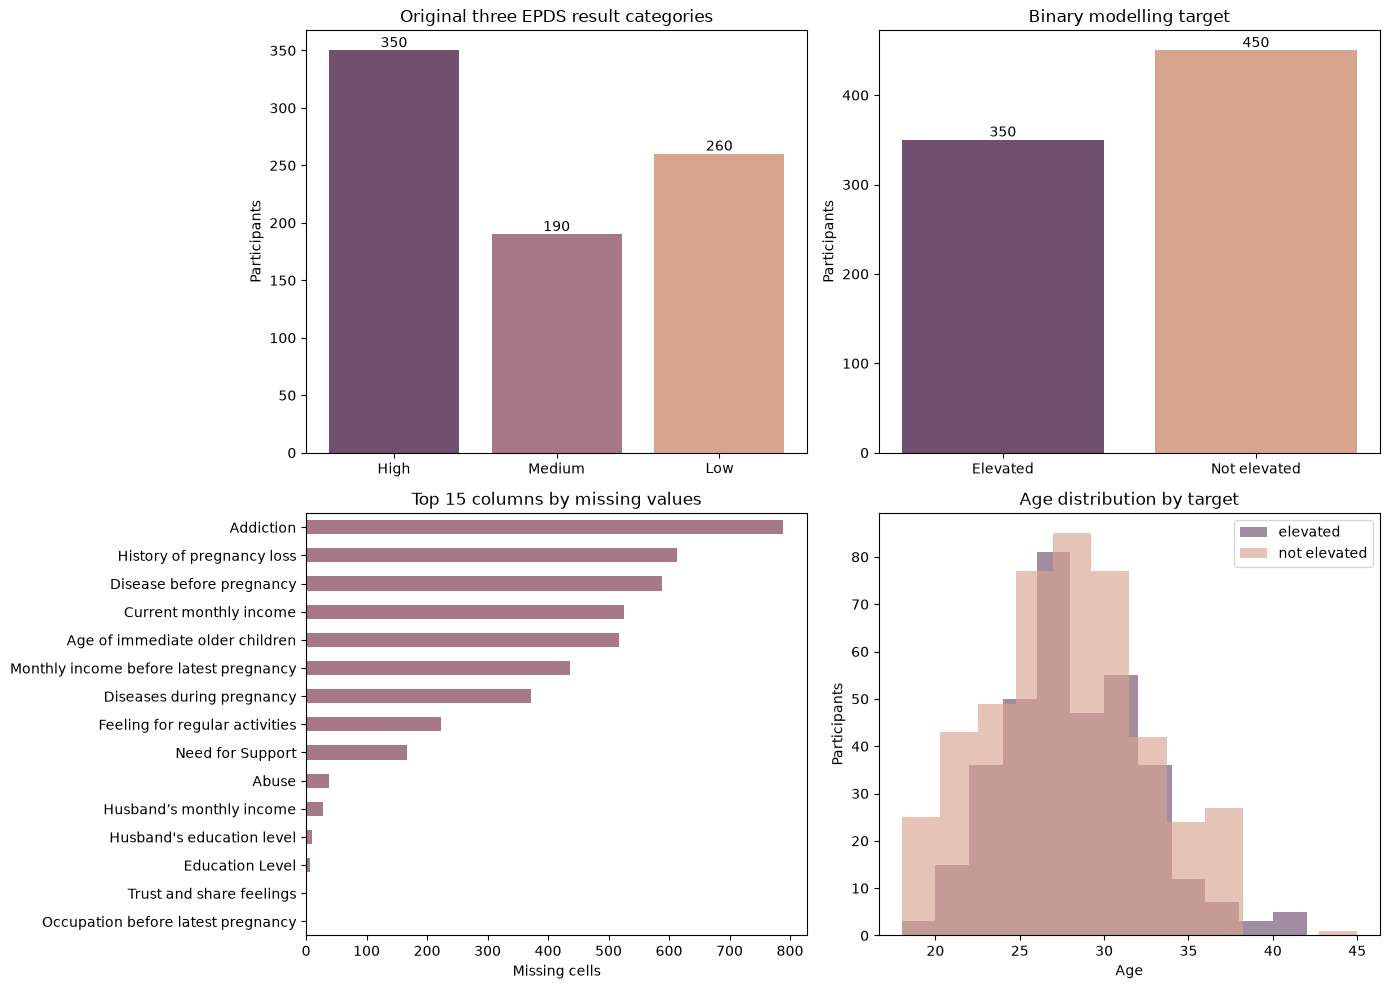

In [3]:
target_binary = df['EPDS Result'].eq('High').map({True: 'elevated', False: 'not_elevated'})
COLORS = {'elevated': '#704f6f', 'not_elevated': '#d8a48f'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epds_counts = df['EPDS Result'].value_counts().reindex(['High', 'Medium', 'Low'])
axes[0, 0].bar(epds_counts.index, epds_counts.values, color=['#704f6f', '#a77887', '#d8a48f'])
axes[0, 0].set(title='Original three EPDS result categories', ylabel='Participants')
for container in axes[0, 0].containers: axes[0, 0].bar_label(container)

binary_counts = target_binary.value_counts().reindex(['elevated', 'not_elevated'])
axes[0, 1].bar(['Elevated', 'Not elevated'], binary_counts, color=[COLORS[x] for x in binary_counts.index])
axes[0, 1].set(title='Binary modelling target', ylabel='Participants')
for container in axes[0, 1].containers: axes[0, 1].bar_label(container)

missing = df.isna().sum().sort_values(ascending=False).head(15).sort_values()
missing.plot.barh(ax=axes[1, 0], color='#a77887')
axes[1, 0].set(title='Top 15 columns by missing values', xlabel='Missing cells')

age = pd.to_numeric(df['Age'], errors='coerce')
for label in ['elevated', 'not_elevated']:
    axes[1, 1].hist(age[target_binary == label].dropna(), bins=12, alpha=.65,
                    label=label.replace('_', ' '), color=COLORS[label])
axes[1, 1].set(title='Age distribution by target', xlabel='Age', ylabel='Participants')
axes[1, 1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** The original target has 350 High, 190 Medium and 260 Low records. Combining Low and Medium creates 350 elevated versus 450 not-elevated cases, so the classes are reasonably balanced. Missingness is substantial in some predictors and is therefore handled inside the pipelines. The overlapping age distributions show that age alone cannot separate the two classes.

## 3. Target, leakage prevention and predictors

The positive class is `EPDS Result == High`. Low and Medium become `not_elevated`. All concurrent EPDS/PHQ questionnaire items, their totals and derived results are excluded. Otherwise, a model could reconstruct the questionnaire score rather than learn from prior/contextual risk factors.

In [4]:
TARGET = 'EPDS Result'
FIRST_SCALE_ITEM = 'Little interest or pleasure in doing things'
scale_start = df.columns.get_loc(FIRST_SCALE_ITEM)
excluded_columns = set(df.columns[scale_start:]) | {'sr', TARGET}
FEATURES = [column for column in df.columns if column not in excluded_columns]
X = df[FEATURES].copy()
y = target_binary.copy()

print('Predictor columns retained:', len(FEATURES))
print('Concurrent questionnaire/derived columns excluded:', len(excluded_columns))
display(pd.DataFrame({'retained predictor': FEATURES}).head(46))

Predictor columns retained: 46
Concurrent questionnaire/derived columns excluded: 24


,retained predictor
0,Age
1,Residence
2,Education Level
3,Marital status
4,Occupation before latest pregnancy
5,Monthly income before latest pregnancy
6,Occupation After Your Latest Childbirth
7,Current monthly income
8,Husband's education level
9,Husband’s monthly income


## 4. Stratified train/validation/test split

- Training: 70% (560 rows), used to fit candidate models.
- Validation: 15% (120 rows), used to compare algorithms and select the winner.
- Test: 15% (120 rows), untouched until after model selection.
- Seed: 42, making the split reproducible.

,rows,elevated,not elevated
Train,560,245,315
Validation,120,52,68
Test,120,53,67


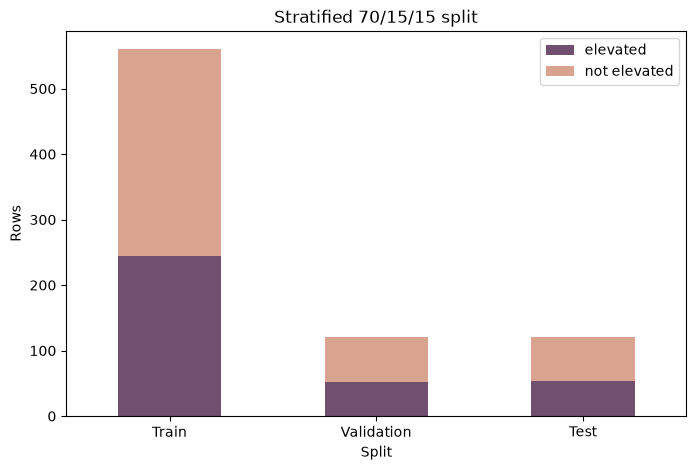

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=.50, stratify=y_temp, random_state=SEED)

split_table = pd.DataFrame({
    'rows': [len(X_train), len(X_val), len(X_test)],
    'elevated': [int((y_train == 'elevated').sum()), int((y_val == 'elevated').sum()), int((y_test == 'elevated').sum())],
    'not elevated': [int((y_train == 'not_elevated').sum()), int((y_val == 'not_elevated').sum()), int((y_test == 'not_elevated').sum())],
}, index=['Train', 'Validation', 'Test'])
display(split_table)
ax = split_table[['elevated', 'not elevated']].plot.bar(stacked=True, figsize=(8, 5),
    color=['#704f6f', '#d8a48f'], title='Stratified 70/15/15 split')
ax.set(ylabel='Rows', xlabel='Split'); ax.tick_params(axis='x', rotation=0)
plt.show()

**Interpretation:** Stratification preserves nearly the same elevated/not-elevated proportion in training, validation and test data. The independent 120-row test set is not used to choose a model.

## 5. Preprocessing and metric definitions

Numerical columns use median imputation and standardisation. Categorical columns use most-frequent imputation and one-hot encoding. Each pipeline learns preprocessing only from its training input.

For the positive `elevated` class:

- Accuracy = `(TP + TN) / all cases`
- Precision = `TP / (TP + FP)`
- Recall = `TP / (TP + FN)`
- F1 = harmonic balance of precision and recall

RMSE is not appropriate because this is classification, not regression.

In [6]:
def make_pipeline(model, feature_columns):
    numeric = [c for c in ['Age', 'Number of the latest pregnancy'] if c in feature_columns]
    categorical = [c for c in feature_columns if c not in numeric]
    preprocess = ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), numeric),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=2)),
        ]), categorical),
    ])
    return Pipeline([('preprocess', preprocess), ('model', model)])

def calculate_metrics(model, features, labels):
    predictions = model.predict(features)
    order = ['elevated', 'not_elevated']
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, pos_label='elevated', zero_division=0),
        'recall': recall_score(labels, predictions, pos_label='elevated', zero_division=0),
        'f1_score': f1_score(labels, predictions, pos_label='elevated', zero_division=0),
        'confusion_matrix': confusion_matrix(labels, predictions, labels=order),
    }

def model_definitions():
    return {
        'Dummy baseline': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED),
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, class_weight='balanced', random_state=SEED),
        'Random Forest': RandomForestClassifier(n_estimators=500, min_samples_leaf=3, class_weight='balanced_subsample', n_jobs=-1, random_state=SEED),
        'Extra Trees': ExtraTreesClassifier(n_estimators=500, min_samples_leaf=3, class_weight='balanced', n_jobs=-1, random_state=SEED),
        'Support Vector Machine': SVC(C=1.0, kernel='rbf', class_weight='balanced', random_state=SEED),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=11, weights='distance'),
    }

## 6. Full 46-predictor experiment: train all seven models

Training time is recorded to demonstrate why classical models finish quickly on 560 rows. Model selection uses validation F1 for the elevated-risk class.

In [7]:
full_models, full_results = {}, {}
for name, estimator in model_definitions().items():
    pipeline = make_pipeline(estimator, FEATURES)
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    result = calculate_metrics(pipeline, X_val, y_val)
    result['fit_seconds'] = elapsed
    full_models[name] = pipeline
    full_results[name] = result

full_comparison = pd.DataFrame({name: {
    'accuracy': value['accuracy'], 'precision': value['precision'],
    'recall': value['recall'], 'f1_score': value['f1_score'],
    'fit_seconds': value['fit_seconds']
} for name, value in full_results.items()}).T
display(full_comparison.sort_values('f1_score', ascending=False).round(4))

  File "C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,accuracy,precision,recall,f1_score,fit_seconds
Random Forest,0.7583,0.7091,0.7500,0.7290,5.1436
Support Vector Machine,0.7417,0.6721,0.7885,0.7257,0.2204
Extra Trees,0.7417,0.6780,0.7692,0.7207,2.8444
Logistic Regression,0.6750,0.6066,0.7115,0.6549,0.2244
K-Nearest Neighbors,0.7583,0.8710,0.5192,0.6506,0.1587
Decision Tree,0.6333,0.5952,0.4808,0.5319,0.1995
Dummy baseline,0.5667,0.0000,0.0000,0.0000,0.2115


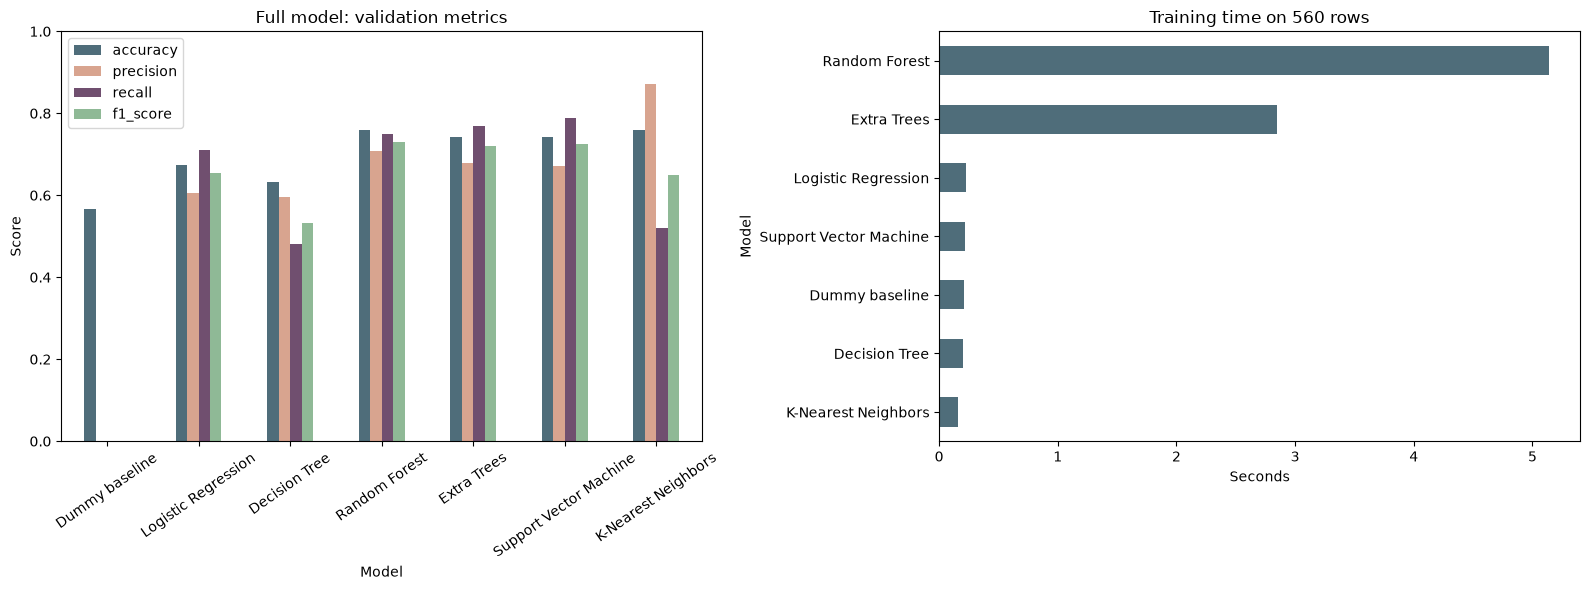

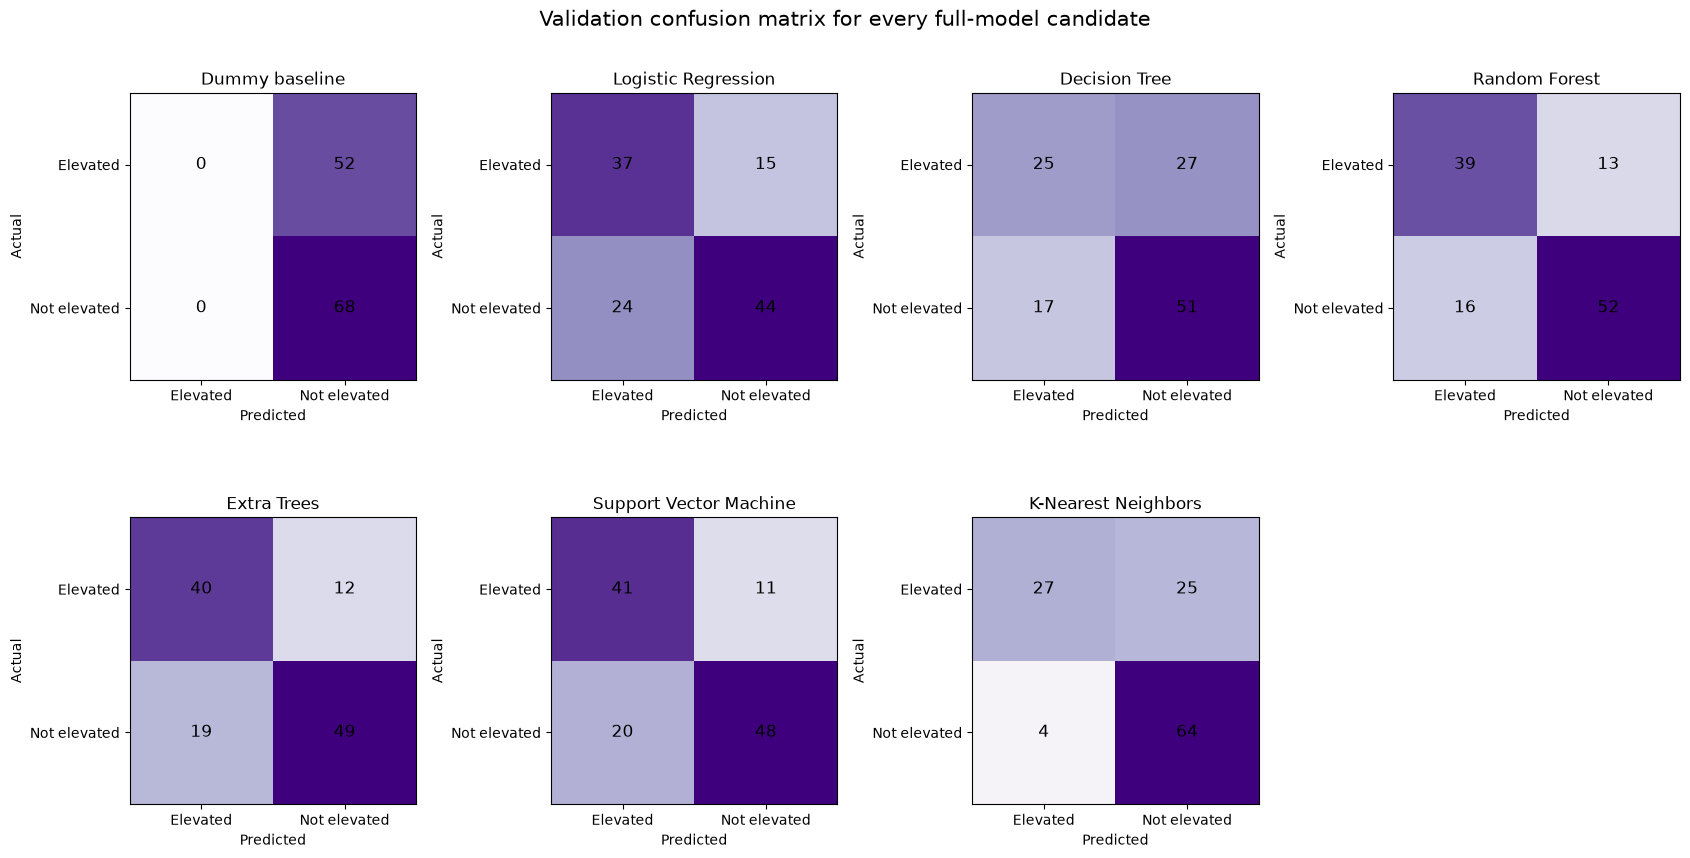

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
full_comparison[['accuracy', 'precision', 'recall', 'f1_score']].plot.bar(
    ax=axes[0], color=['#4f6d7a', '#d8a48f', '#704f6f', '#8fb996'])
axes[0].set(title='Full model: validation metrics', ylabel='Score', ylim=(0, 1), xlabel='Model')
axes[0].tick_params(axis='x', rotation=35)
full_comparison['fit_seconds'].sort_values().plot.barh(ax=axes[1], color='#4f6d7a')
axes[1].set(title='Training time on 560 rows', xlabel='Seconds', ylabel='Model')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for ax, (name, result) in zip(axes.flat, full_results.items()):
    matrix = result['confusion_matrix']
    ax.imshow(matrix, cmap='Purples', vmin=0, vmax=max(1, matrix.max()))
    for row in range(2):
        for col in range(2): ax.text(col, row, matrix[row, col], ha='center', va='center', fontsize=12)
    ax.set_xticks([0, 1], ['Elevated', 'Not elevated'])
    ax.set_yticks([0, 1], ['Elevated', 'Not elevated'])
    ax.set(title=name, xlabel='Predicted', ylabel='Actual')
axes.flat[-1].axis('off')
fig.suptitle('Validation confusion matrix for every full-model candidate', fontsize=15)
plt.tight_layout(); plt.show()

**Interpretation:** Random Forest provides the strongest validation F1-score, while the dummy model never identifies an elevated case. The timing chart explains why training is quick: even the ensemble models take only seconds on 560 rows. The confusion matrices show the exact correct and incorrect validation predictions behind each metric.

## 7. Select winner, refit, and evaluate the untouched test set once

Random Forest wins by validation F1. Its configuration is refitted using train + validation rows, then evaluated once on the untouched test rows.

,untouched test score
accuracy,0.8083
precision,0.7679
recall,0.8113
f1_score,0.7890


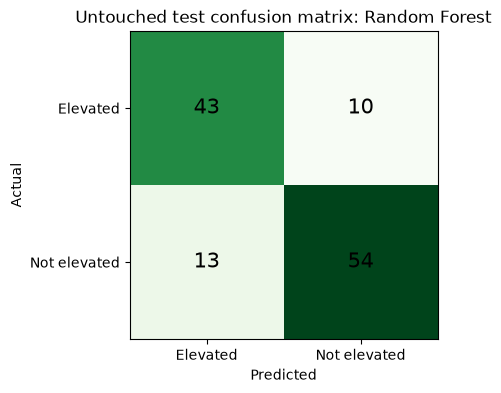

,manually recomputed from confusion matrix
accuracy,0.8083
precision,0.7679
recall,0.8113
f1_score,0.7890


In [9]:
full_winner_name = full_comparison['f1_score'].idxmax()
X_fit, y_fit = pd.concat([X_train, X_val]), pd.concat([y_train, y_val])
full_winner = make_pipeline(model_definitions()[full_winner_name], FEATURES)
full_winner.fit(X_fit, y_fit)
full_test = calculate_metrics(full_winner, X_test, y_test)

display(pd.Series({k: v for k, v in full_test.items() if k != 'confusion_matrix'},
                  name='untouched test score').round(4).to_frame())
cm = full_test['confusion_matrix']
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Greens')
for row in range(2):
    for col in range(2): ax.text(col, row, cm[row, col], ha='center', va='center', fontsize=15)
ax.set_xticks([0, 1], ['Elevated', 'Not elevated']); ax.set_yticks([0, 1], ['Elevated', 'Not elevated'])
ax.set(title=f'Untouched test confusion matrix: {full_winner_name}', xlabel='Predicted', ylabel='Actual')
plt.show()

tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
manual_check = pd.Series({
    'accuracy': (tp + tn) / cm.sum(), 'precision': tp / (tp + fp),
    'recall': tp / (tp + fn), 'f1_score': 2 * tp / (2 * tp + fp + fn)
}, name='manually recomputed from confusion matrix')
display(manual_check.round(4).to_frame())

**Interpretation:** On 120 untouched cases, Random Forest correctly identifies 43 of 53 elevated cases and misses 10. It also produces 13 false elevated-risk alerts. The manually recomputed values confirm that the reported accuracy, precision, recall and F1 come directly from these counts.

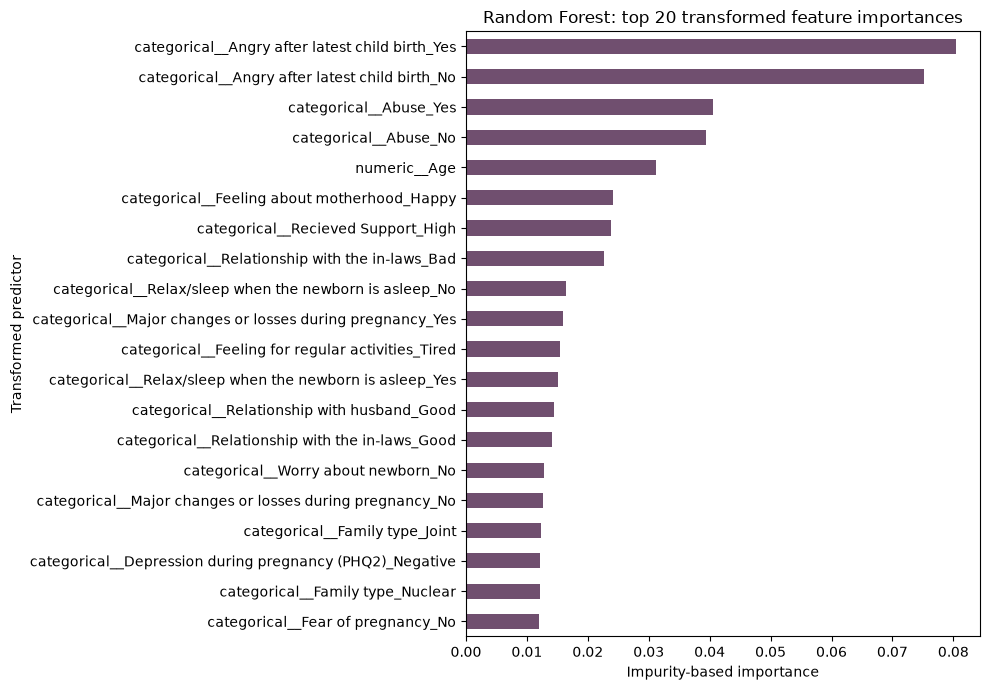

In [10]:
# Explain the selected Random Forest using its transformed feature importances.
feature_names = full_winner.named_steps['preprocess'].get_feature_names_out()
importances = full_winner.named_steps['model'].feature_importances_
importance_table = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
ax = importance_table.sort_values().plot.barh(figsize=(10, 7), color='#704f6f',
    title='Random Forest: top 20 transformed feature importances')
ax.set(xlabel='Impurity-based importance', ylabel='Transformed predictor')
plt.tight_layout(); plt.show()

**Interpretation:** The importance chart shows which transformed predictors most influenced Random Forest decisions. Importance indicates predictive contribution within this dataset; it does not prove that a factor causes postpartum depression.

## 8. Reduced 15-input guided check-in experiment

The deployed check-in cannot reasonably ask 46 questions. This second experiment repeats the full procedure using 15 understandable inputs. The same original split indices and seven algorithms are used.

In [11]:
CHECKIN_FEATURES = [
    'Age', 'Relationship with husband', 'Relationship with the newborn',
    'Feeling about motherhood', 'Recieved Support', 'Need for Support', 'Abuse',
    'Trust and share feelings', 'Worry about newborn',
    'Relax/sleep when newborn is tended ', 'Relax/sleep when the newborn is asleep',
    'Angry after latest child birth', 'Feeling for regular activities',
    'Depression before pregnancy (PHQ2)', 'Depression during pregnancy (PHQ2)',
]
CX_train, CX_val, CX_test = X_train[CHECKIN_FEATURES], X_val[CHECKIN_FEATURES], X_test[CHECKIN_FEATURES]
checkin_models, checkin_results = {}, {}
for name, estimator in model_definitions().items():
    # Match the deployed tree depth while preserving the same seven algorithm families.
    if name == 'Decision Tree':
        estimator = DecisionTreeClassifier(max_depth=7, min_samples_leaf=5, class_weight='balanced', random_state=SEED)
    pipeline = make_pipeline(estimator, CHECKIN_FEATURES)
    start = time.perf_counter(); pipeline.fit(CX_train, y_train); elapsed = time.perf_counter() - start
    result = calculate_metrics(pipeline, CX_val, y_val); result['fit_seconds'] = elapsed
    checkin_models[name], checkin_results[name] = pipeline, result

checkin_comparison = pd.DataFrame({name: {
    'accuracy': value['accuracy'], 'precision': value['precision'],
    'recall': value['recall'], 'f1_score': value['f1_score'], 'fit_seconds': value['fit_seconds']
} for name, value in checkin_results.items()}).T
display(checkin_comparison.sort_values('f1_score', ascending=False).round(4))

,accuracy,precision,recall,f1_score,fit_seconds
Logistic Regression,0.7417,0.6780,0.7692,0.7207,0.1215
Support Vector Machine,0.7250,0.6667,0.7308,0.6972,0.3264
Random Forest,0.7250,0.6727,0.7115,0.6916,4.9541
Decision Tree,0.7250,0.6792,0.6923,0.6857,0.0606
Extra Trees,0.7000,0.6379,0.7115,0.6727,2.6591
K-Nearest Neighbors,0.7000,0.6667,0.6154,0.6400,0.0657
Dummy baseline,0.5667,0.0000,0.0000,0.0000,0.0589


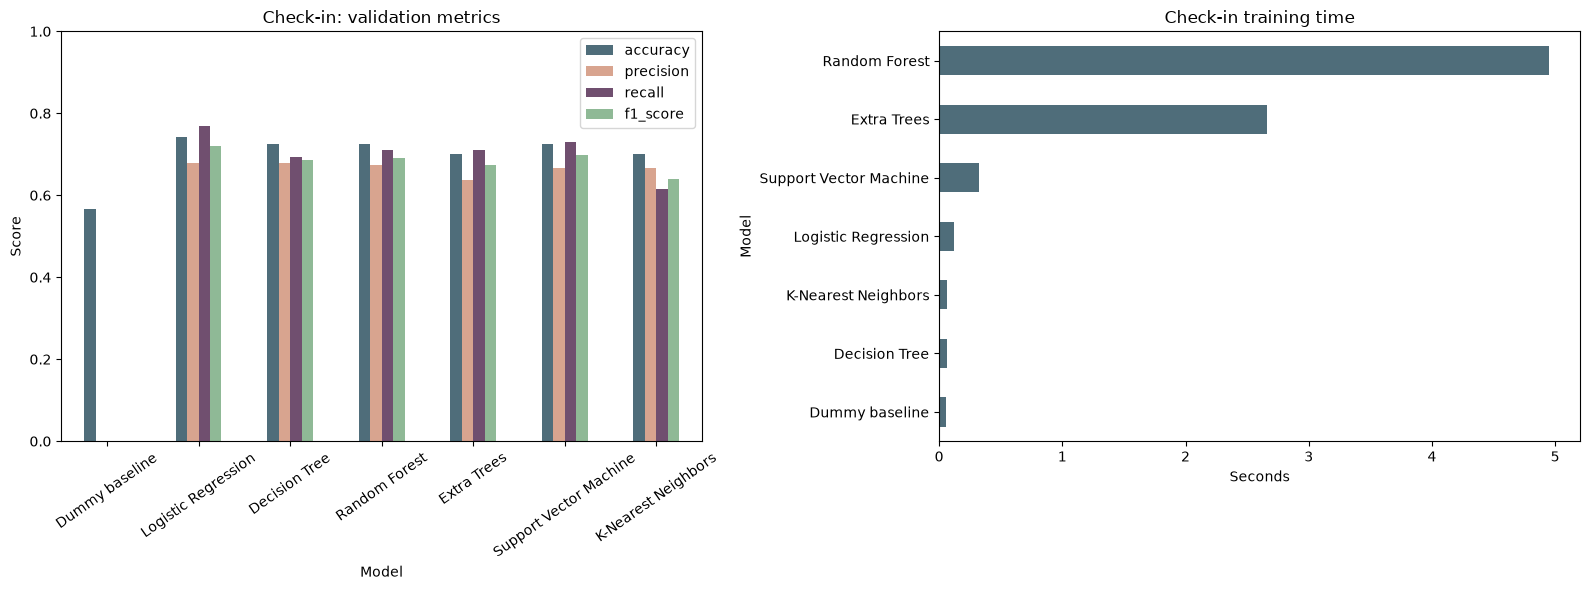

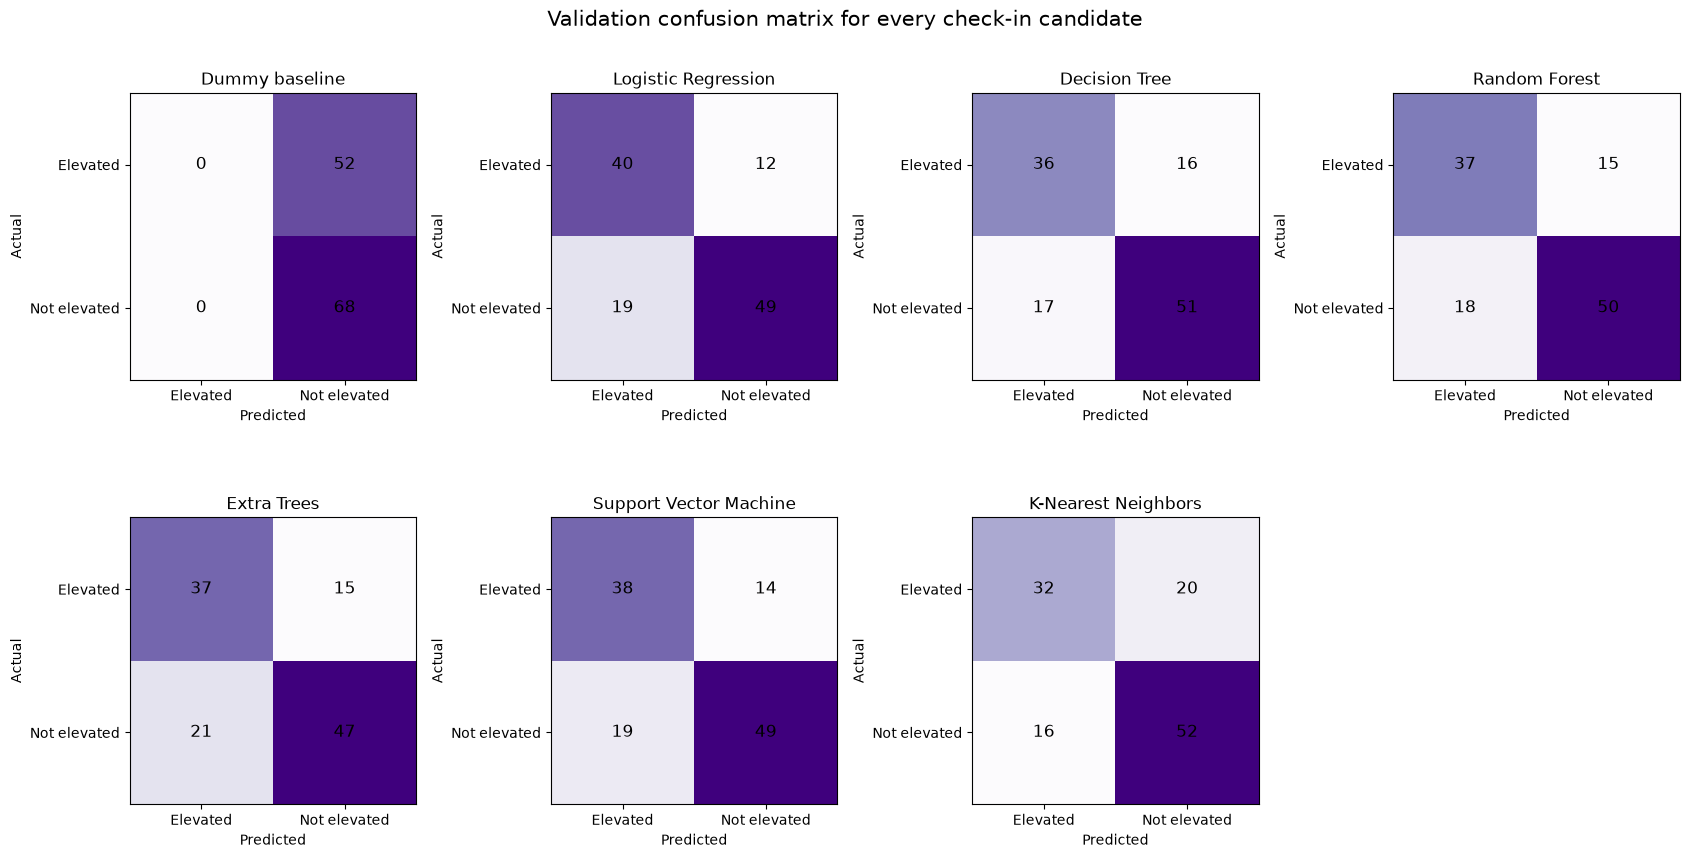

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
checkin_comparison[['accuracy', 'precision', 'recall', 'f1_score']].plot.bar(
    ax=axes[0], color=['#4f6d7a', '#d8a48f', '#704f6f', '#8fb996'])
axes[0].set(title='Check-in: validation metrics', ylabel='Score', ylim=(0, 1), xlabel='Model')
axes[0].tick_params(axis='x', rotation=35)
checkin_comparison['fit_seconds'].sort_values().plot.barh(ax=axes[1], color='#4f6d7a')
axes[1].set(title='Check-in training time', xlabel='Seconds', ylabel='Model')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for ax, (name, result) in zip(axes.flat, checkin_results.items()):
    matrix = result['confusion_matrix']; ax.imshow(matrix, cmap='Purples')
    for row in range(2):
        for col in range(2): ax.text(col, row, matrix[row, col], ha='center', va='center', fontsize=12)
    ax.set_xticks([0, 1], ['Elevated', 'Not elevated']); ax.set_yticks([0, 1], ['Elevated', 'Not elevated'])
    ax.set(title=name, xlabel='Predicted', ylabel='Actual')
axes.flat[-1].axis('off')
fig.suptitle('Validation confusion matrix for every check-in candidate', fontsize=15)
plt.tight_layout(); plt.show()

**Interpretation:** With only 15 user-friendly inputs, Logistic Regression has the best validation F1. Performance remains stronger than the dummy baseline, while the confusion matrices expose the different trade-offs between missed elevated cases and false alerts.

,untouched test score
accuracy,0.7667
precision,0.7049
recall,0.8113
f1_score,0.7544


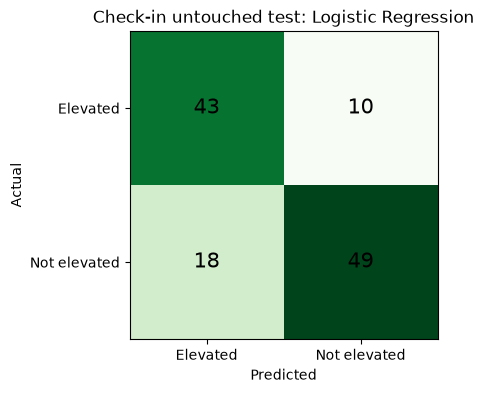

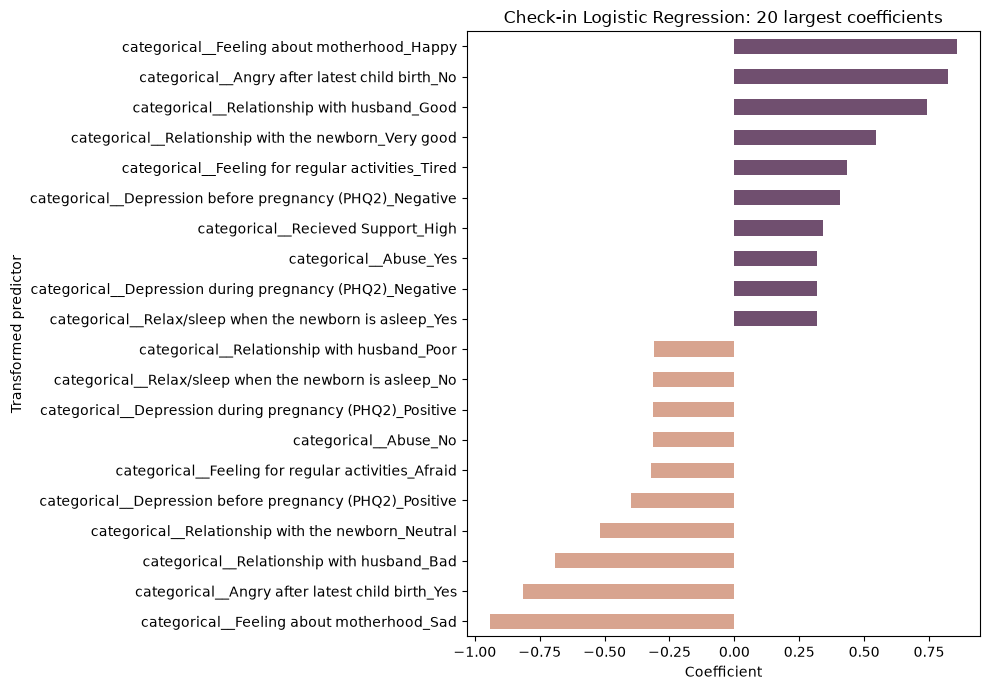

In [13]:
checkin_winner_name = checkin_comparison['f1_score'].idxmax()
checkin_winner = make_pipeline(model_definitions()[checkin_winner_name], CHECKIN_FEATURES)
checkin_winner.fit(pd.concat([CX_train, CX_val]), pd.concat([y_train, y_val]))
checkin_test = calculate_metrics(checkin_winner, CX_test, y_test)
display(pd.Series({k: v for k, v in checkin_test.items() if k != 'confusion_matrix'},
                  name='untouched test score').round(4).to_frame())

cm2 = checkin_test['confusion_matrix']
fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(cm2, cmap='Greens')
for row in range(2):
    for col in range(2): ax.text(col, row, cm2[row, col], ha='center', va='center', fontsize=15)
ax.set_xticks([0, 1], ['Elevated', 'Not elevated']); ax.set_yticks([0, 1], ['Elevated', 'Not elevated'])
ax.set(title=f'Check-in untouched test: {checkin_winner_name}', xlabel='Predicted', ylabel='Actual')
plt.show()

# Logistic Regression coefficients: magnitude indicates stronger influence, not causation.
coef_names = checkin_winner.named_steps['preprocess'].get_feature_names_out()
coefs = checkin_winner.named_steps['model'].coef_[0]
coef_table = pd.Series(coefs, index=coef_names).sort_values(key=abs, ascending=False).head(20)
ax = coef_table.sort_values().plot.barh(figsize=(10, 7), color=['#d8a48f' if x < 0 else '#704f6f' for x in coef_table.sort_values()])
ax.set(title='Check-in Logistic Regression: 20 largest coefficients', xlabel='Coefficient', ylabel='Transformed predictor')
plt.tight_layout(); plt.show()

**Interpretation:** The reduced check-in correctly identifies 43 of 53 elevated test cases but creates more false alerts than the full model. Positive and negative coefficient directions describe associations with the model's encoded class; their magnitude reflects influence, not medical causation.

## 9. Save the two models and reproducible metrics

Saving occurs only after the experiment is complete. The application loads these fitted pipelines; it does not retrain models for every user request.

In [14]:
(ROOT / 'models').mkdir(exist_ok=True)
joblib.dump(full_winner, ROOT / 'models' / 'ppd_screening_risk.joblib')
joblib.dump(checkin_winner, ROOT / 'models' / 'ppd_checkin_risk.joblib')

summary = pd.DataFrame({
    'Full screening model': [full_winner_name, *[full_test[k] for k in ['accuracy', 'precision', 'recall', 'f1_score']]],
    'Reduced check-in model': [checkin_winner_name, *[checkin_test[k] for k in ['accuracy', 'precision', 'recall', 'f1_score']]],
}, index=['selected model', 'accuracy', 'precision', 'recall', 'f1_score'])
display(summary)

,Full screening model,Reduced check-in model
selected model,Random Forest,Logistic Regression
accuracy,0.808333,0.766667
precision,0.767857,0.704918
recall,0.811321,0.811321
f1_score,0.788991,0.754386


## 10. Conversational component: bilingual source-grounded retrieval

The 800 tabular rows train screening classifiers; they do not contain conversational answers. The chatbot therefore uses a separate 14-topic, source-attributed English/Kinyarwanda knowledge collection. The Kinyarwanda renderings require native-speaker review.

At runtime: user text → deterministic safety/scope checks → language selection → TF-IDF retrieval → optional local Ollama phrasing → disclaimer and sources. The Ollama model is pretrained and Modelfile customization is not fine-tuning.

In [15]:
knowledge = json.loads(KNOWLEDGE.read_text(encoding='utf-8'))
print('Knowledge topics:', len(knowledge))
display(pd.DataFrame([{
    'topic': row['topic'], 'source': row['source'], 'has English': bool(row.get('text_en')),
    'has Kinyarwanda': bool(row.get('text_rw')), 'review status': row.get('review_status', '')
} for row in knowledge]))

retrievers = {}
for language in ['en', 'rw']:
    qkey, textkey = f'queries_{language}', f'text_{language}'
    searchable = [f"{row.get(qkey, '')} {row.get(textkey, '')}" for row in knowledge]
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True)
    matrix = vectorizer.fit_transform(searchable)
    retrievers[language] = (vectorizer, matrix)

def retrieve(query, language='en', top_k=3):
    vectorizer, matrix = retrievers[language]
    similarities = cosine_similarity(vectorizer.transform([query]), matrix)[0]
    indexes = similarities.argsort()[::-1][:top_k]
    return [(knowledge[i], float(similarities[i])) for i in indexes]

queries = [
    ('I cannot sleep and I feel exhausted', 'en'),
    ('I feel guilty and like a bad mother', 'en'),
    ('Sinshobora gusinzira kandi ndananiwe', 'rw'),
    ('Numva mfite agahinda nyuma yo kubyara', 'rw'),
]
retrieval_results = []
for query, language in queries:
    row, score = retrieve(query, language, 1)[0]
    retrieval_results.append({'query': query, 'language': language, 'retrieved topic': row['topic'], 'similarity': score})
display(pd.DataFrame(retrieval_results).round(3))

Knowledge topics: 14


,topic,source,has English,has Kinyarwanda,review status
0,normal emotional changes,WHO World Health Day 2025,True,True,source-grounded; Kinyarwanda requires native-s...
1,persistent sadness,WHO Perinatal Mental Health,True,True,source-grounded; Kinyarwanda requires native-s...
2,anxiety and worry,WHO World Health Day 2025,True,True,source-grounded; Kinyarwanda requires native-s...
3,feeling overwhelmed,WHO Perinatal Mental Health Integration Guide,True,True,source-grounded; Kinyarwanda requires native-s...
4,sleep and fatigue,WHO World Health Day 2025,True,True,source-grounded; Kinyarwanda requires native-s...
5,guilt and self-blame,WHO Perinatal Mental Health Integration Guide,True,True,source-grounded; Kinyarwanda requires native-s...
6,social support,WHO Postnatal Care Recommendations,True,True,source-grounded; Kinyarwanda requires native-s...
7,partner and family support,WHO Postnatal Care Recommendations,True,True,source-grounded; Kinyarwanda requires native-s...
8,loss and grief,WHO World Health Day 2025,True,True,source-grounded; Kinyarwanda requires native-s...
9,bonding and emotional connection,WHO Perinatal Mental Health,True,True,source-grounded; Kinyarwanda requires native-s...


,query,language,retrieved topic,similarity
0,I cannot sleep and I feel exhausted,en,sleep and fatigue,0.413
1,I feel guilty and like a bad mother,en,guilt and self-blame,0.363
2,Sinshobora gusinzira kandi ndananiwe,rw,sleep and fatigue,0.346
3,Numva mfite agahinda nyuma yo kubyara,rw,persistent sadness,0.402


## 11. System architecture and what is actually trained

| Component | Method | Trained by this project? |
|---|---|---|
| Full screening model | Seven algorithms compared; Random Forest selected | Yes |
| Reduced check-in model | Seven algorithms compared; Logistic Regression selected | Yes |
| Language detector | Existing project classifier | Previously trained |
| Retrieval | Character TF-IDF over 14 evidence topics | Fitted/indexed, not generative training |
| Response phrasing | Local `umubyeyi` Ollama model based on Gemma 3 4B | No; pretrained and instruction-customized |
| Safety routing | Deterministic rules | Authored, not trained |

`/api/chat` is only the local application endpoint connecting the browser to this pipeline. It is not an external model and does not train anything.

## 12. Conclusions and limitations

- Classical training is fast because there are only 560 training rows and 15–46 predictors; this is fundamentally different from language-model training.
- Random Forest full-model test results: accuracy 0.8083, precision 0.7679, recall 0.8113, F1 0.7890.
- Logistic Regression check-in test results: accuracy 0.7667, precision 0.7049, recall 0.8113, F1 0.7544.
- Results are held-out experimental performance, not diagnosis or clinical validation.
- The data is from Bangladesh, covers up to 24 months postpartum, and is not limited to first-time mothers.
- The chatbot requires a separate reviewed conversational dataset before defensible language-model fine-tuning can be claimed.